# 数据预处理

In [1]:
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"文本长度: {len(text)}")
print(f"文本前100个字符:\n{text[:100]}")
# 获取所有字符的集合，并排好序
chars = sorted(list(set(text)))

# 生成char到int的映射词典
char2idx = {ch: idx for idx, ch in enumerate(chars)}
# 生成int到char的映射词典
idx2char = {idx: ch for idx, ch in enumerate(chars)}

print(f"Total chars: {len(chars)}")
print(f"Example char2idx: {list(char2idx.items())[:10]}")
print(f"Example idx2char: {list(idx2char.items())[:10]}")


文本长度: 1115394
文本前100个字符:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
Total chars: 65
Example char2idx: [('\n', 0), (' ', 1), ('!', 2), ('$', 3), ('&', 4), ("'", 5), (',', 6), ('-', 7), ('.', 8), ('3', 9)]
Example idx2char: [(0, '\n'), (1, ' '), (2, '!'), (3, '$'), (4, '&'), (5, "'"), (6, ','), (7, '-'), (8, '.'), (9, '3')]


In [2]:
# 将文本转换为数字序列
import numpy as np
text_as_int = np.array([char2idx[c] for c in text]) #把全部文本都变为id
print(len(text_as_int))
text_as_int[:20]

1115394


array([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43,
       44, 53, 56])

In [3]:
# 定义序列长度和批次大小
import torch
from torch.utils.data import Dataset, DataLoader

seq_length = 100  # 每个样本的序列长度
batch_size = 64   # 每个批次的样本数量

# 创建自定义数据集类
class ShakespeareDataset(Dataset):
    def __init__(self, text_as_int, seq_length):
        self.text_as_int = text_as_int
        self.seq_length = seq_length
        self.sub_len = seq_length + 1 #一个样本的长度
        
    def __len__(self):
        # 计算可能的序列数量
        return len(self.text_as_int)//(self.seq_length+1) #+1是因为要预测下一个字符
        
    def __getitem__(self, idx):
        # 将numpy数组转换为长整型(Long)
        return torch.tensor(self.text_as_int[idx*self.sub_len:(idx+1)*self.sub_len], dtype=torch.long)

# 定义collate函数，用于处理批次数据
def collate_fct(batch):
    # print(batch)
    # 将批次数据堆叠成张量，确保类型为long
    batch = torch.stack(batch)
    # 输入序列是除了最后一个字符的所有字符
    input_batch = batch[:, :-1]
    # 目标序列是除了第一个字符的所有字符
    target_batch = batch[:, 1:]
    return input_batch, target_batch

# 创建数据集实例
shakespeare_dataset = ShakespeareDataset(text_as_int, seq_length)

# 创建数据加载器
dataloader = DataLoader(shakespeare_dataset, batch_size=batch_size, shuffle=True, drop_last=True, collate_fn=collate_fct)

# 打印示例，查看输入和目标
for input_batch, target_batch in dataloader:
    print(f"输入批次形状: {input_batch.shape}")
    print(f"目标批次形状: {target_batch.shape}")
    
    # 打印第一个样本的输入和目标
    print(input_batch)
    print(target_batch)
    break

print(f"\n数据集大小: {len(shakespeare_dataset)}")
print(f"批次数量: {len(dataloader)}")


输入批次形状: torch.Size([64, 100])
目标批次形状: torch.Size([64, 100])
tensor([[43, 56, 60,  ..., 50, 50,  1],
        [ 1, 58, 46,  ..., 59, 50, 42],
        [13, 14, 17,  ...,  1, 51, 63],
        ...,
        [53, 61, 52,  ..., 39, 56, 42],
        [41, 58, 47,  ...,  1, 44, 53],
        [57, 58,  8,  ...,  0, 27, 56]])
tensor([[56, 60, 63,  ..., 50,  1, 39],
        [58, 46, 43,  ..., 50, 42,  1],
        [14, 17, 24,  ..., 51, 63,  1],
        ...,
        [61, 52,  1,  ..., 56, 42,  1],
        [58, 47, 53,  ..., 44, 53, 53],
        [58,  8,  0,  ..., 27, 56, 42]])

数据集大小: 11043
批次数量: 172


In [4]:
import torch.nn as nn
import torch.nn.functional as F

# 定义RNN模型
class ShakespeareRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, batch_size):
        super(ShakespeareRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=1,
            bidirectional=False,
            batch_first=True
        )
        self.dense = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden=None):
        # 输入形状: [batch_size, sequence_length]
        x = self.embedding(x)  # 形状: [batch_size, sequence_length, embedding_dim]
        output, hidden = self.rnn(x, hidden)  # 形状: [batch_size, sequence_length, hidden_dim]
        output = self.dense(output)  # 形状: [batch_size, sequence_length, vocab_size]
        return output, hidden
    


# 定义模型参数
vocab_size = len(char2idx)  # 词汇表大小
embedding_dim = 256  # 嵌入维度
rnn_units = 1024  # RNN单元数量

# 实例化模型
model = ShakespeareRNN(vocab_size, embedding_dim, rnn_units, batch_size)
print(model)


ShakespeareRNN(
  (embedding): Embedding(65, 256)
  (rnn): RNN(256, 1024, batch_first=True)
  (dense): Linear(in_features=1024, out_features=65, bias=True)
)


In [5]:
# 编写前向计算验证模型是否ok
sample_input = torch.randint(0, vocab_size, (batch_size, seq_length), dtype=torch.long)
sample_output, sample_hidden = model(sample_input)
print("输入 shape:", sample_input.shape)
print("输出 shape:", sample_output.shape)
print("隐藏状态 shape:", sample_hidden.shape)


输入 shape: torch.Size([64, 100])
输出 shape: torch.Size([64, 100, 65])
隐藏状态 shape: torch.Size([1, 64, 1024])


In [6]:
tensor = torch.randn(3, 4)
print(tensor)
tensor_reshaped = tensor.reshape(-1)
print(tensor_reshaped.shape)


tensor([[-0.3466, -0.9484, -2.3227,  0.5183],
        [-1.4023,  1.6240, -0.2351, -0.1990],
        [-0.0832, -0.5033, -1.8877, -1.1465]])
torch.Size([12])


# 训练

In [7]:
from tqdm.auto import tqdm
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练函数
def train_step(model, dataloader, optimizer, criterion, epochs=5):
    losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct_predictions = 0
        total_predictions = 0
        
        # 使用tqdm创建进度条
        with tqdm(dataloader, desc=f"轮次 {epoch+1}/{epochs}") as pbar:
            for input_batch, target_batch in pbar:
                input_batch = input_batch.to(device)
                target_batch = target_batch.to(device)
                optimizer.zero_grad()
                
                # 前向传播
                output, _ = model(input_batch)
                
                # 计算损失
                # 重塑输出和目标以适应CrossEntropyLoss,因为给入的output要是二维的
                output = output.reshape(-1, vocab_size)
                target_batch = target_batch.reshape(-1)
                
                loss = criterion(output, target_batch)
                
                # 反向传播
                loss.backward()
                optimizer.step()
                
                # 计算准确率
                _, predicted = torch.max(output, 1)
                correct_predictions += (predicted == target_batch).sum().item()
                total_predictions += target_batch.size(0)
                
                current_loss = loss.item()
                epoch_loss += current_loss
                
                # 更新进度条显示的损失值和准确率
                current_acc = correct_predictions / total_predictions
                pbar.set_postfix({"损失": f"{current_loss:.4f}", "准确率": f"{current_acc:.2%}"})
        
        # 计算并记录每个epoch的平均损失
        avg_epoch_loss = epoch_loss / len(dataloader)
        losses.append(avg_epoch_loss)
        avg_epoch_acc = correct_predictions / total_predictions
        print(f"轮次 {epoch+1}/{epochs} 完成, 平均损失: {avg_epoch_loss:.4f}, 平均准确率: {avg_epoch_acc:.2%}")
    
    return losses

# 将模型移动到设备上
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 开始训练循环
losses = train_step(model, dataloader, optimizer, criterion, epochs=5)
  

轮次 1/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 1/5 完成, 平均损失: 2.0168, 平均准确率: 42.05%


轮次 2/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 2/5 完成, 平均损失: 1.6227, 平均准确率: 51.50%


轮次 3/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 3/5 完成, 平均损失: 1.5056, 平均准确率: 54.49%


轮次 4/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 4/5 完成, 平均损失: 1.4438, 平均准确率: 55.95%


轮次 5/5:   0%|          | 0/172 [00:00<?, ?it/s]

轮次 5/5 完成, 平均损失: 1.4004, 平均准确率: 57.04%


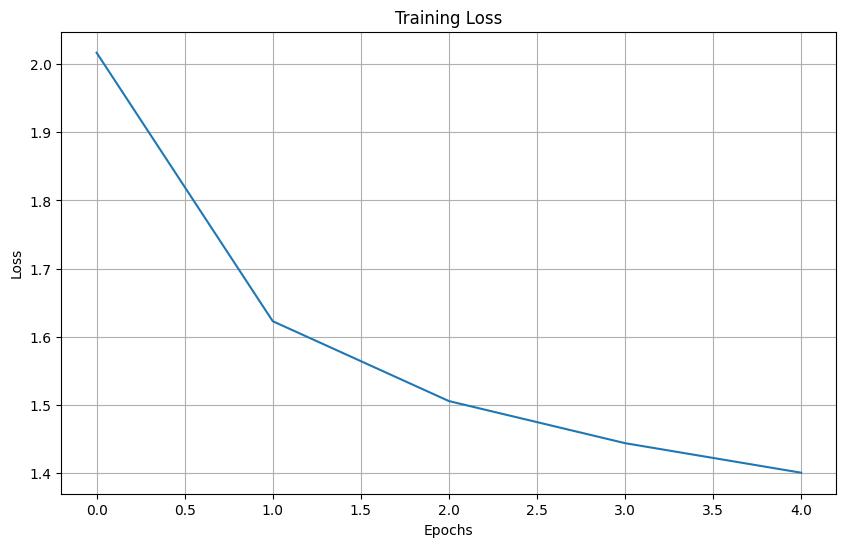

In [8]:
import matplotlib.pyplot as plt
# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 预测

In [9]:
# 理解torch.multinomial函数的小例子
import torch
import torch.nn.functional as F

# 创建一个概率分布
probs = torch.tensor([0.1, 0.2, 0.3, 0.4])
print("概率分布:", probs)

# 从概率分布中采样一个元素
sample = torch.multinomial(probs, num_samples=1)
print("采样一个元素:", sample.item(), "对应概率:", probs[sample.item()].item())

概率分布: tensor([0.1000, 0.2000, 0.3000, 0.4000])
采样一个元素: 3 对应概率: 0.4000000059604645


原始logits值: tensor([1.0000, 2.0000, 5.0000, 3.0000, 0.5000])

temperature=0.5时的概率分布:
tensor([3.2848e-04, 2.4272e-03, 9.7919e-01, 1.7934e-02, 1.2084e-04])

temperature=1.0时的概率分布:
tensor([0.0151, 0.0410, 0.8234, 0.1114, 0.0091])

temperature=2.0时的概率分布:
tensor([0.0739, 0.1218, 0.5459, 0.2008, 0.0575])


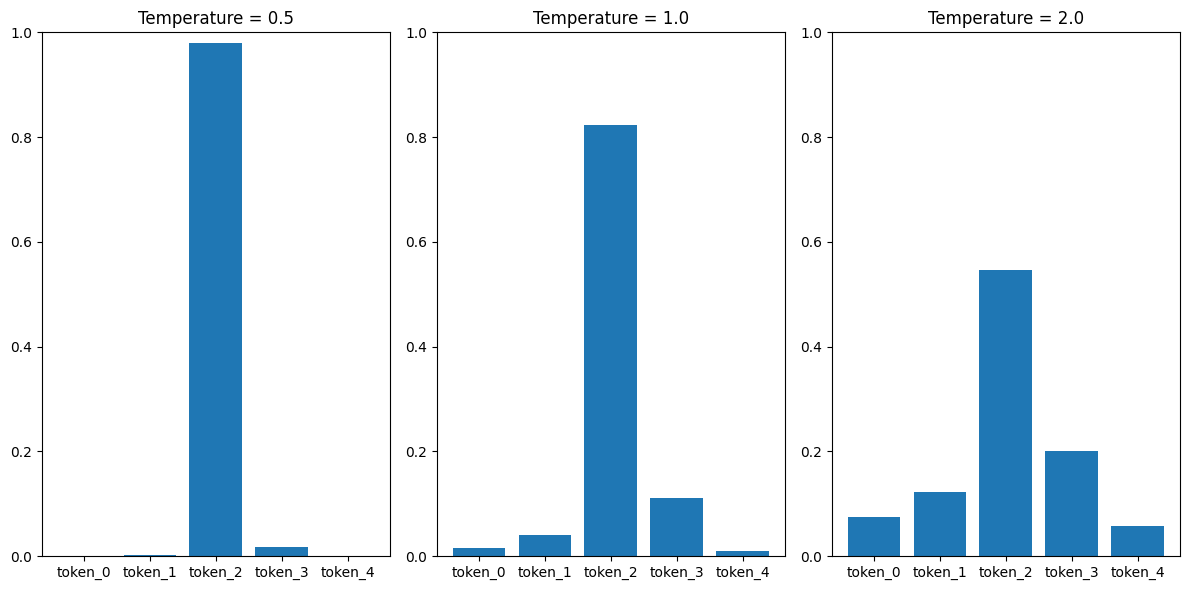


解释:
- 较低的temperature (如0.5) 使概率分布更加尖锐，最高概率的token被选中的可能性更大
- 标准temperature (1.0) 保持原始概率分布
- 较高的temperature (如2.0) 使概率分布更加平坦，增加了采样的随机性


In [10]:
# 展示temperature参数对softmax输出的影响
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 创建一个模拟的logits输出
logits = torch.tensor([1.0, 2.0, 5.0, 3.0, 0.5])
print("原始logits值:", logits)

# 使用不同的temperature值
temperatures = [0.5, 1.0, 2.0]

plt.figure(figsize=(12, 6))

for i, temp in enumerate(temperatures):
    # 应用temperature
    scaled_logits = logits / temp
    
    # 应用softmax获取概率分布
    probabilities = F.softmax(scaled_logits, dim=0)
    
    # 打印结果
    print(f"\ntemperature={temp}时的概率分布:")
    print(probabilities)
    
    # 可视化
    plt.subplot(1, len(temperatures), i+1)
    plt.bar(range(len(probabilities)), probabilities.numpy())
    plt.title(f"Temperature = {temp}")
    plt.ylim(0, 1)
    plt.xticks(range(len(probabilities)), [f"token_{i}" for i in range(len(probabilities))])

plt.tight_layout()
plt.show()

print("\n解释:")
print("- 较低的temperature (如0.5) 使概率分布更加尖锐，最高概率的token被选中的可能性更大")
print("- 标准temperature (1.0) 保持原始概率分布")
print("- 较高的temperature (如2.0) 使概率分布更加平坦，增加了采样的随机性")


# 温度是解码策略之一

In [11]:
# 生成文本函数
def generate_text(model, start_string, char2idx, idx2char, num_generate=1000, temperature=1.0):
    # 将模型设置为评估模式
    model.eval()
    
    # 将起始字符串转换为索引
    input_indices = [char2idx[char] for char in start_string]
    input_tensor = torch.tensor(input_indices, dtype=torch.long).unsqueeze(0).to(device) #unsqueeze(0) 在第0维上增加一个维度
    print(input_tensor.shape) #(1,5)
    # 存储生成的文本
    generated_text = start_string
    
    # 隐藏状态初始化为None，模型会自动初始化
    hidden = None
    
    # 生成指定数量的字符
    with torch.no_grad():
        for _ in range(num_generate):
            # 获取模型预测
            output, hidden = model(input_tensor,hidden)
            
            # 应用温度参数调整预测分布
            logits = output[:, -1, :] / temperature
            
            # 从调整后的分布中采样下一个字符
            probabilities = F.softmax(logits, dim=-1)
            predicted_id = torch.multinomial(probabilities, 1) #从概率分布中采样一个元素，概率越大，被选中的可能性越大
            
            # 将预测的字符添加到生成文本中
            generated_char = idx2char[predicted_id.item()]
            generated_text += generated_char #放入到生成序列
            
            # 更新输入张量为当前预测的字符
            input_tensor = predicted_id
    
    return generated_text

generate_text(model, 'hello',char2idx,idx2char)

torch.Size([1, 5])


"hellongoor badk, the father for another, walk me.\n\nLUCIO:\nProccept so breathes peize about the struck'd it; and this go so sard canniancy:\nHave I would not rays England's paintandect a word which I repare of the heagine have speak against these armounter?\n\nFirst Must thou dost thou shalt you woe\nTo chyet against I read, serve me save me, Frantionly and feetle, you forth?\n\nKING HENRY VI:\nWhy, there is a appey, fair for his days!\nLet then Sonscenes afternais but noil'd it you up two\nshows was golder. Prithee brands you are a pardly disceptured in love and I presently,\nTo can never by hist\nons instnument I say show you:\nI hare no less a father:\nEnglone's dear?\n\nLUCENCUS:\nThus, good stands, patertorwer to the\ncellow of his life.\n\nhave I umperning defencet the dead!\nWhat carew our phy their poor treason? O heavens, traitor, cherourly so you.\n\nSICINIUS:\nI know the lime to;\nI pour use your kindness, with wedger:\nThe galdings, you mean is no more: O, July at oarly 